In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2, invgamma, norm, multivariate_normal
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf
import pymc as pm 
import arviz as az

In [42]:
df = pd.read_csv("cleanedbaysian.csv")
df["arr_delay_log"] = np.log1p(df["arr_delay"])

df["log_carrier_delay"] = np.log1p(df["carrier_delay"])
#df["log_weather_delay"] = np.log1p(df["weather_delay"])
#df["log_security_delay"] = np.log1p(df["security_delay"])
#df["log_nas_delay"] = np.log1p(df["nas_delay"])
#df["log_late_aircraft_delay"] = np.log1p(df["late_aircraft_delay"])

# Use delay columns instead of counts
features = [
    "log_carrier_delay",
    "weather_delay",
    "nas_delay",       
    "late_aircraft_delay",
    "security_delay"
]

target = "arr_delay_log"

# Drop missing values
df = df[features + [target]].dropna()

# Remove outliers using IQR (there are outliers messing up current data)
Q1 = df[target].quantile(0.25)
Q3 = df[target].quantile(0.75)
IQR = Q3 - Q1
df = df[(df[target] >= Q1 - 1.5*IQR) & (df[target] <= Q3 + 1.5*IQR)]

# Subsample (dataset too large)
N = 1000
df = df.sample(n=N, random_state=42)  

X = df[features].values
y = df[target].values

In [43]:
print(df["arr_delay_log"].describe())


count    1000.000000
mean        7.046312
std         1.559639
min         2.833213
25%         6.047338
50%         7.060476
75%         8.033172
max        11.122265
Name: arr_delay_log, dtype: float64


In [44]:
# scale
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / X_std

print(X_scaled.shape, y.shape)


(1000, 5) (1000,)


In [45]:
with pm.Model() as model:

    # Priors for coefficients
    beta = pm.Normal("beta", mu=0, sigma=1, shape=X_scaled.shape[1])
    
    # Prior for intercept
    intercept = pm.Normal("intercept", mu=0, sigma=1)
    
    # Prior for noise
    sigma = pm.HalfNormal("sigma", sigma=1)
    
    # Expected value
    mu = intercept + pm.math.dot(X_scaled, beta)
    
    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)
    
    # Sampling (posterior)
    trace = pm.sample(2000, tune=1000, target_accept=0.9, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, intercept, sigma]


/Users/deekshitamadhalam/anaconda3/envs/bayes_clean/lib/python3.11/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 3 seconds.


In [46]:
# Summary of posterior
summary = az.summary(trace)
print(summary)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]    1.140  0.025   1.090    1.184        0.0      0.0    9616.0   
beta[1]    0.082  0.028   0.029    0.132        0.0      0.0   10113.0   
beta[2]    0.166  0.029   0.110    0.219        0.0      0.0    7819.0   
beta[3]    0.239  0.030   0.184    0.298        0.0      0.0    7731.0   
beta[4]    0.005  0.022  -0.038    0.045        0.0      0.0   11649.0   
intercept  7.043  0.022   7.004    7.086        0.0      0.0   12354.0   
sigma      0.668  0.015   0.642    0.698        0.0      0.0   12172.0   

           ess_tail  r_hat  
beta[0]      5955.0    1.0  
beta[1]      6451.0    1.0  
beta[2]      6332.0    1.0  
beta[3]      6552.0    1.0  
beta[4]      6415.0    1.0  
intercept    5858.0    1.0  
sigma        6207.0    1.0  


In [47]:
# Extract posterior means
beta_means = trace.posterior["beta"].mean(dim=["chain", "draw"]).values

for i, feature in enumerate(features):
    print(f"{feature}: {beta_means[i]}")

log_carrier_delay: 1.1395132347639858
weather_delay: 0.08222469253657935
nas_delay: 0.16590885602628336
late_aircraft_delay: 0.23924267861047263
security_delay: 0.00464503231192569


In [48]:
# Rank features
importance = pd.Series(beta_means, index=features)
importance = importance.sort_values(ascending=False)

print("Most important delay factors:")
print(importance)

Most important delay factors:
log_carrier_delay      1.139513
late_aircraft_delay    0.239243
nas_delay              0.165909
weather_delay          0.082225
security_delay         0.004645
dtype: float64


array([[<Axes: title={'center': 'beta\n0'}>,
        <Axes: title={'center': 'beta\n1'}>,
        <Axes: title={'center': 'beta\n2'}>],
       [<Axes: title={'center': 'beta\n3'}>,
        <Axes: title={'center': 'beta\n4'}>,
        <Axes: title={'center': 'intercept'}>],
       [<Axes: title={'center': 'sigma'}>, <Axes: >, <Axes: >]],
      dtype=object)

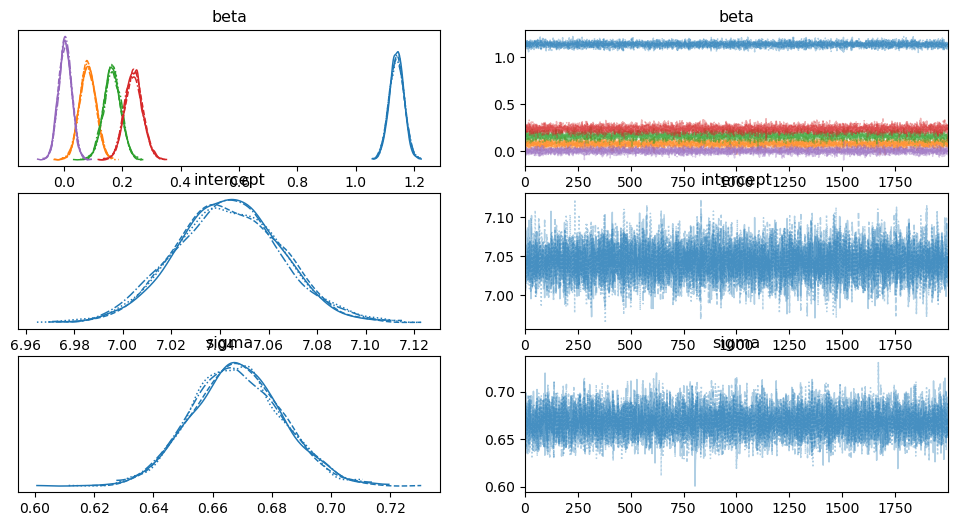

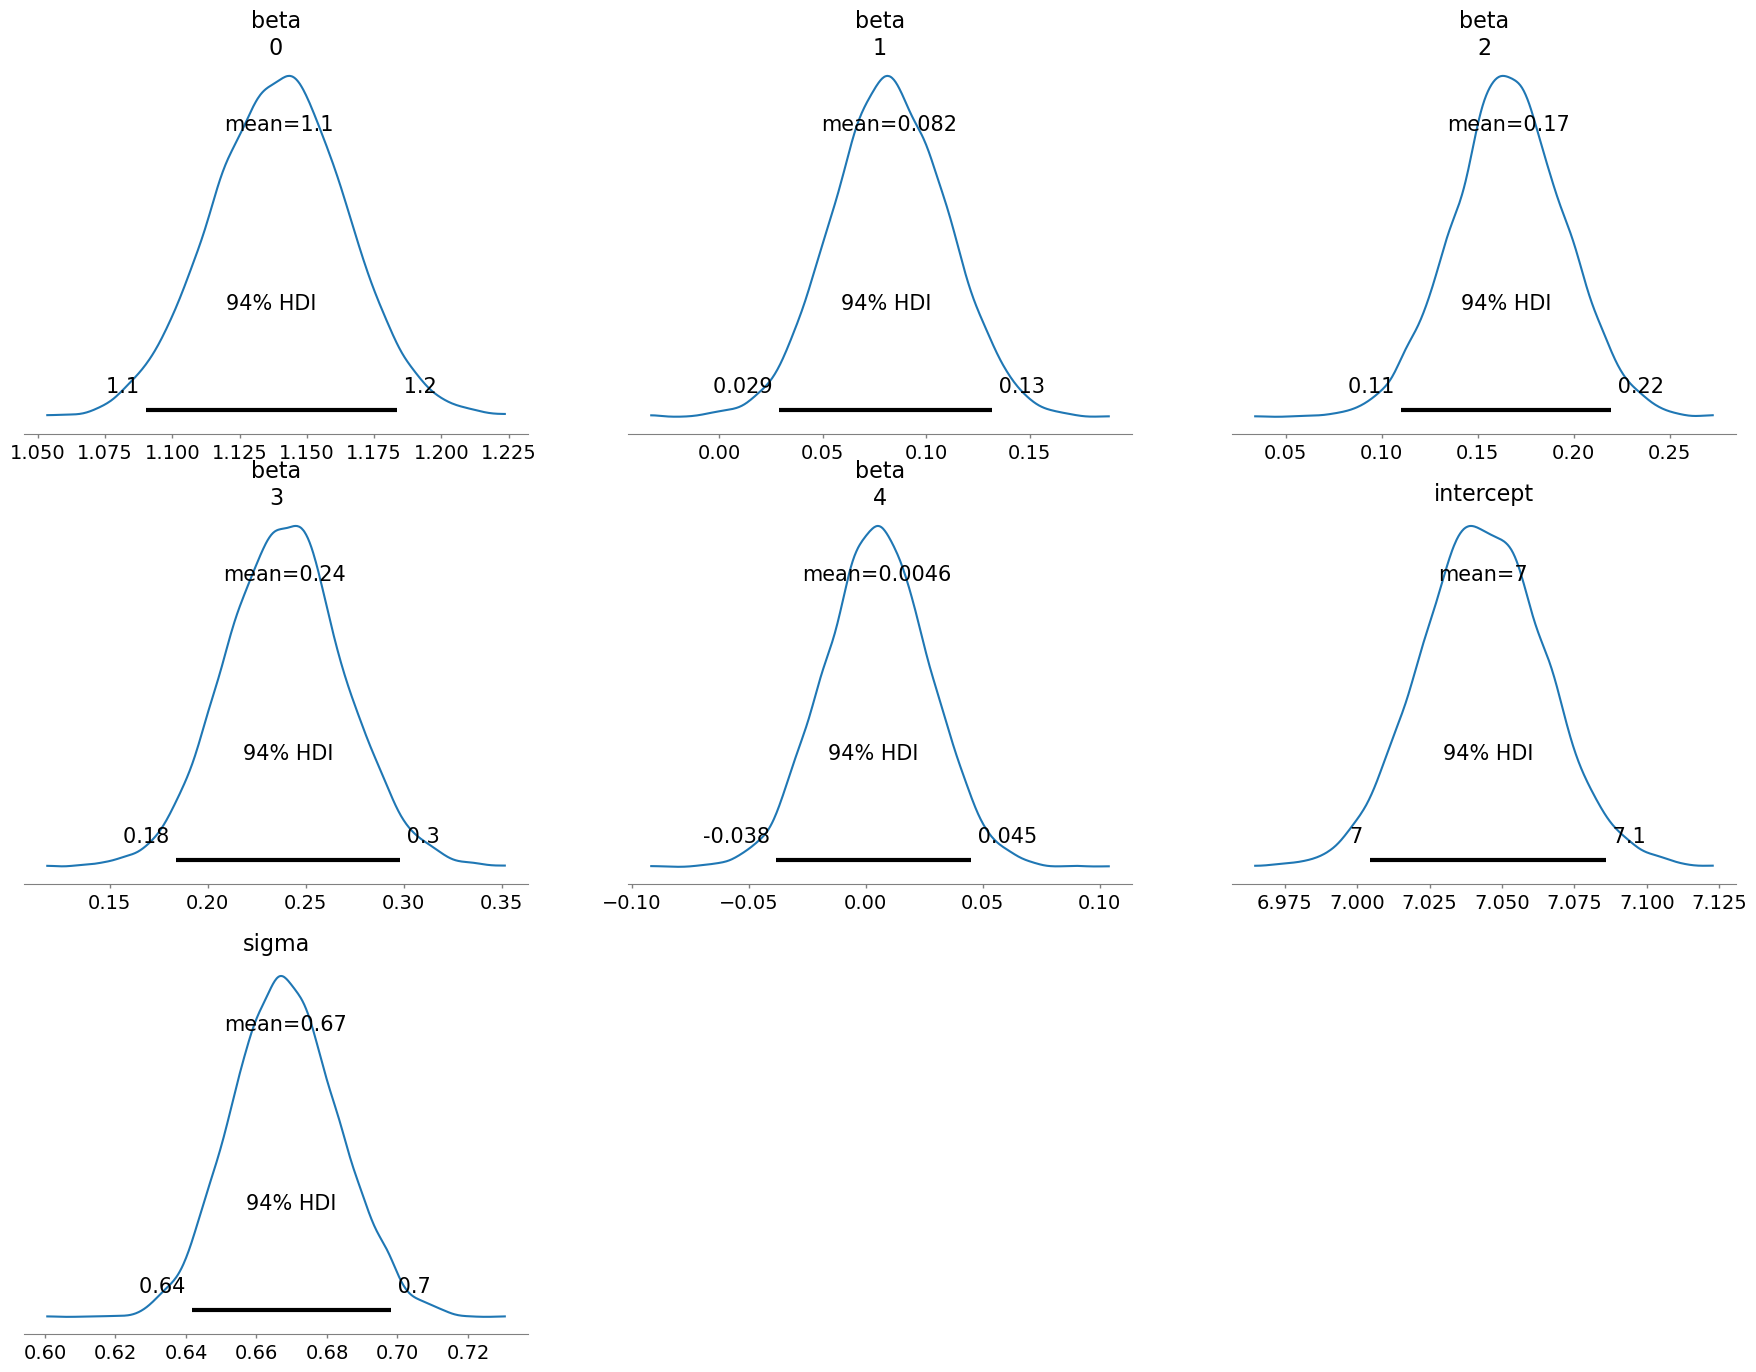

In [49]:
# Trace plots (check convergence)
az.plot_trace(trace)

# Posterior distributions
az.plot_posterior(trace)

Sampling: [y_obs]


/Users/deekshitamadhalam/anaconda3/envs/bayes_clean/lib/python3.11/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

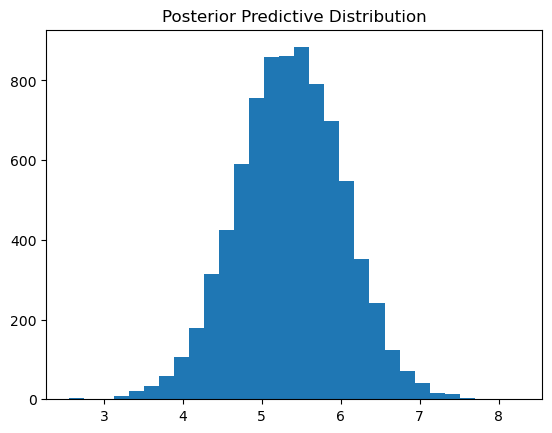

In [50]:
with model:
    ppc = pm.sample_posterior_predictive(trace, var_names=["y_obs"])

# Plot for observation
plt.hist(ppc.posterior_predictive['y_obs'][:,:,0].values.ravel(), bins=30)
plt.title("Posterior Predictive Distribution")
plt.show()

In [51]:
preds = ppc.posterior_predictive['y_obs'].values.ravel()
print("Predicted mean:", np.mean(preds))
print("Actual value:", y[0])

Predicted mean: 7.043256814604678
Actual value: 4.07753744390572


In [52]:
# Get posterior predictive mean for all observations
ppc_means = ppc.posterior_predictive['y_obs'].mean(dim=["chain", "draw"]).values

# RMSE
rmse = np.sqrt(np.mean((y - ppc_means)**2))
print("RMSE:", rmse)

RMSE: 0.6660093482099727


In [53]:
ss_res = np.sum((y - ppc_means)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - (ss_res / ss_tot)
print(f"R² Score: {r2 * 100:.2f}%")

R² Score: 81.75%
